Implement block matching using SAD (Sum of Absolute Differences) to estimate motion between two images

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.color import rgb2gray

def sad(block1, block2):
    return np.sum(np.abs(block1 - block2))

In [2]:
def block_matching_sad(img_ref, img_target, block_size, search_window_size):
    h, w = img_ref.shape
    motion_vectors = np.zeros(((h // block_size), (w // block_size), 2))

    half_block = block_size // 2
    half_search = search_window_size // 2

    for i in range(0, h - block_size + 1, block_size):
        for j in range(0, w - block_size + 1, block_size):
            ref_block = img_ref[i:i+block_size, j:j+block_size]

            min_sad = float('inf')
            best_dx, best_dy = 0, 0

            # Define search window boundaries
            search_row_start = max(0, i - half_search)
            search_row_end = min(h - block_size, i + half_search)
            search_col_start = max(0, j - half_search)
            search_col_end = min(w - block_size, j + half_search)

            for r in range(search_row_start, search_row_end + 1):
                for c in range(search_col_start, search_col_end + 1):
                    target_block = img_target[r:r+block_size, c:c+block_size]
                    current_sad = sad(ref_block, target_block)

                    if current_sad < min_sad:
                        min_sad = current_sad
                        best_dx = c - j
                        best_dy = r - i

            motion_vectors[i // block_size, j // block_size, 0] = best_dx
            motion_vectors[i // block_size, j // block_size, 1] = best_dy

    return motion_vectors

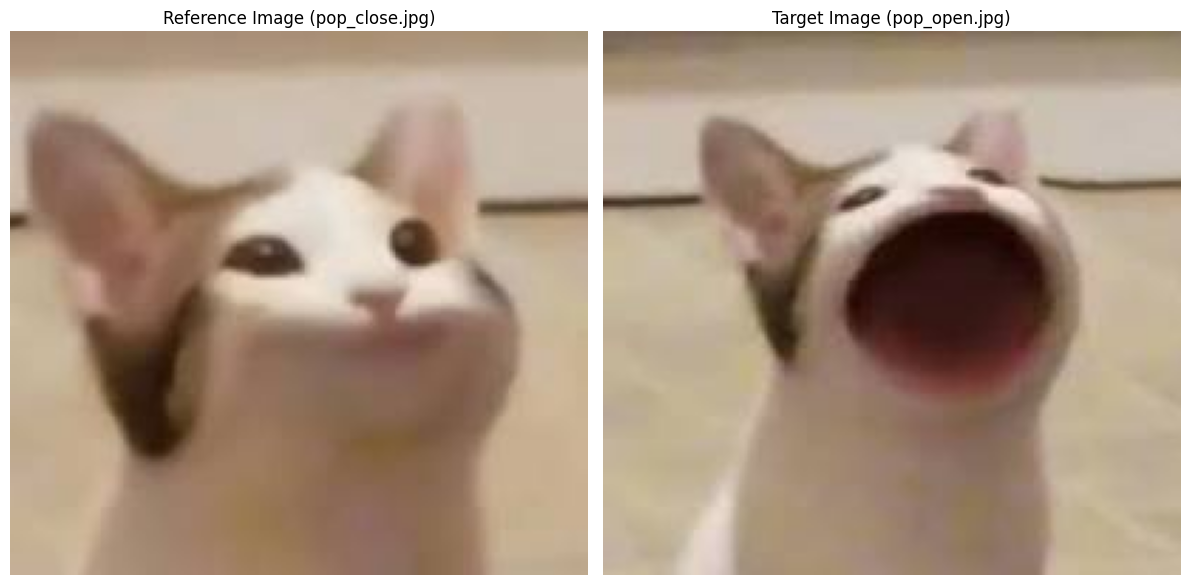

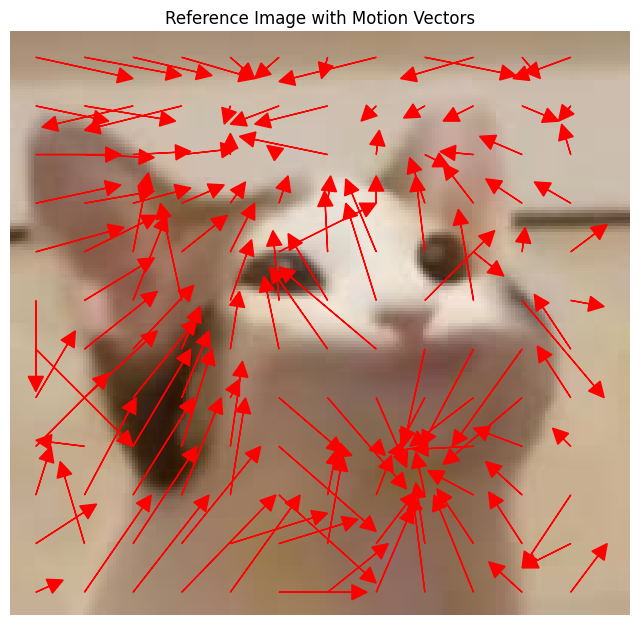

In [7]:
image1_color = plt.imread('/content/pop_close.jpg')
image2_color = plt.imread('/content/pop_open.jpg')

# Convert images to grayscale for block matching
image1 = rgb2gray(image1_color)
image2 = rgb2gray(image2_color)

block_size = 16
search_window_size = 64

# Estimate motion vectors
motion_vectors = block_matching_sad(image1, image2, block_size, search_window_size)

# Visualize the results
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(image1_color)
ax[0].set_title('Reference Image (pop_close.jpg)')
ax[0].axis('off')

ax[1].imshow(image2_color)
ax[1].set_title('Target Image (pop_open.jpg)')
ax[1].axis('off')

plt.tight_layout()
plt.show()

# Visualize motion vectors on the reference image
plt.figure(figsize=(8, 8))
plt.imshow(image1_color)
plt.title('Reference Image with Motion Vectors')

h, w = image1.shape
for i in range(motion_vectors.shape[0]):
    for j in range(motion_vectors.shape[1]):
        # Calculate the center of the current block
        center_x = j * block_size + block_size // 2
        center_y = i * block_size + block_size // 2

        dx = motion_vectors[i, j, 0]
        dy = motion_vectors[i, j, 1]

        # Plot the motion vector
        # Scale dx, dy for better visualization if needed, otherwise use raw values
        plt.arrow(center_x, center_y, dx, dy, color='r', head_width=5, head_length=5, length_includes_head=True)

plt.axis('off')
plt.show()